# Transfer Diagnostics for Synthetic IPv6

This notebook investigates why the synthetic IPv6 dataset performed poorly in the earlier model runs. It compares the UNSW feature space with the synthetic feature space using shared columns, overlap checks, PCA projections, and optional UMAP projections.

The purpose is diagnostic, not a unified model comparison. It helps explain whether the synthetic data is too far from the UNSW distribution for models trained on UNSW to transfer well.


In [2]:
import os
import json
import zipfile
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

ROOTS = [Path.cwd(), Path("/mnt/data")]
OUT = Path("artifacts/transfer_diagnostics")
OUT.mkdir(parents=True, exist_ok=True)

def find_all(pattern):
    hits = []
    for root in ROOTS:
        if root.exists():
            hits.extend(root.rglob(pattern))
    out, seen = [], set()
    for p in hits:
        s = str(p.resolve())
        if s not in seen:
            out.append(p)
            seen.add(s)
    return out

def find_first(patterns):
    for pat in patterns:
        hits = find_all(pat)
        if hits:
            return hits[0]
    return None

UNSW_TRAIN_CSV = "/kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_training-set.csv"
UNSW_TEST_CSV = "/kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_testing-set.csv"

ARTIFACT_DIRS = {"/kaggle/input/datasets/models-and-results-unsw/final_model_artifacts"
}

print("UNSW train csv:", UNSW_TRAIN_CSV)
print("UNSW test csv :", UNSW_TEST_CSV)
print("Artifact dirs :", ARTIFACT_DIRS)
print("Output dir    :", OUT.resolve())


UNSW train csv: /kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_training-set.csv
UNSW test csv : /kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_testing-set.csv
Artifact dirs : {'/kaggle/input/datasets/models-and-results-unsw/final_model_artifacts'}
Output dir    : /kaggle/working/artifacts/transfer_diagnostics


## Load UNSW and Synthetic Data

The notebook loads UNSW-NB15 and the synthetic IPv6 splits, then rebuilds the synthetic train, validation, and test tables from `flows.csv` and the split files. This gives both domains in a common format for transfer diagnostics.


In [5]:
unsw_test = pd.read_csv(UNSW_TEST_CSV)
if UNSW_TRAIN_CSV is not None:
    unsw_train = pd.read_csv(UNSW_TRAIN_CSV)
else:
    unsw_train = None

def normalize_attack_name(x):
    if pd.isna(x):
        return "Unknown"
    s = str(x).strip()
    if s.lower() == "normal":
        return "Benign"
    return s

def load_synthetic_bundle():
    flows = pd.read_csv("/kaggle/input/datasets/synthetic-data/synthetic_ipv6_grounded_v4_balanced_32x32/synthetic_ipv6_grounded_v4_balanced_32x32/flows.csv")
    train_split = pd.read_csv("/kaggle/input/datasets/synthetic-data/synthetic_ipv6_grounded_v4_balanced_32x32/synthetic_ipv6_grounded_v4_balanced_32x32/train.csv")
    val_split = pd.read_csv("/kaggle/input/datasets/synthetic-data/synthetic_ipv6_grounded_v4_balanced_32x32/synthetic_ipv6_grounded_v4_balanced_32x32/test.csv")
    test_split = pd.read_csv("/kaggle/input/datasets/synthetic-data/synthetic_ipv6_grounded_v4_balanced_32x32/synthetic_ipv6_grounded_v4_balanced_32x32/val.csv")

    syn_train = flows.merge(train_split[["record_id"]], on="record_id", how="inner")
    syn_val = flows.merge(val_split[["record_id"]], on="record_id", how="inner")
    syn_test = flows.merge(test_split[["record_id"]], on="record_id", how="inner")
    return flows, syn_train, syn_val, syn_test

syn_flows, syn_train, syn_val, syn_test = load_synthetic_bundle()

print("UNSW test shape:", unsw_test.shape)
print("Synthetic test shape:", syn_test.shape)

display(unsw_test.head(2))
display(syn_test.head(2))


UNSW test shape: (175341, 45)
Synthetic test shape: (55082, 55)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ip_version,src_ip_v6,dst_ip_v6,ipv6_flow_label,ipv6_next_header,ipv6_hop_limit,ipv6_ext_hdr_count,ipv6_fragment_count,label_name,record_id
0,60757,0.000005,udp,-,INT,2,0,158.79413,0.000000,263801.712139,...,6,2001:db8:5101:83b1:b653:122d:ecc3:9230,2001:db8:1:e6df:ac01:1c64:a485:7044:a453,726234,udp,32,2,2,Shellcode,rec_0000001
1,49960,0.347759,tcp,http,FIN,75,14,80086.97042,616.321652,246.939191,...,6,2001:db8:e96:c59:b704:a0f3:7481:2d12,2001:db8:1:87a2:b009:e168:9747:8d56:a86e,823737,tcp,32,2,1,Worms,rec_0000004


## Task Preparation Helpers

Binary and multiclass task builders are defined for both domains. The helpers normalize labels and produce matching feature and target arrays so the same diagnostic code can be applied to both tasks.


In [6]:
def prepare_unsw_task(task="multiclass"):
    tr = unsw_train.copy() if unsw_train is not None else unsw_test.copy()
    te = unsw_test.copy()

    if task == "multiclass":
        target = "attack_cat"
        tr[target] = tr[target].apply(normalize_attack_name)
        te[target] = te[target].apply(normalize_attack_name)
        drop_cols = ["id", "label"]
        labels = sorted(pd.Series(tr[target]).unique().tolist())
    else:
        target = "label"
        tr[target] = tr[target].astype(str).map(lambda x: "Attack" if str(x) == "1" else "Benign")
        te[target] = te[target].astype(str).map(lambda x: "Attack" if str(x) == "1" else "Benign")
        drop_cols = ["id", "attack_cat"]
        labels = ["Benign", "Attack"]

    X_train_full = tr.drop(columns=[target] + drop_cols, errors="ignore").reset_index(drop=True)
    y_train_full = tr[target].astype(str).values
    X_test = te.drop(columns=[target] + drop_cols, errors="ignore").reset_index(drop=True)
    y_test = te[target].astype(str).values
    return X_train_full, y_train_full, X_test, y_test, labels

def prepare_synthetic_task(task="multiclass"):
    te = syn_test.copy()
    if task == "multiclass":
        te["label"] = te["label"].astype(str).apply(lambda s: "Benign" if str(s).lower() == "normal" else str(s))
        labels = sorted(pd.Series(te["label"]).unique().tolist())
    else:
        te["label"] = te["label"].astype(str).map(lambda x: "Benign" if x == "Benign" else "Attack")
        labels = ["Benign", "Attack"]

    X_test = te.drop(columns=["label", "record_id", "window_start_utc", "window_end_utc", "src_ip", "dst_ip"], errors="ignore")
    y_test = te["label"].astype(str).values
    return te, None, X_test.reset_index(drop=True), y_test, labels

for task in ["binary", "multiclass"]:
    X_unsw, y_unsw, _, _, labels = prepare_unsw_task(task)
    _, _, X_syn, y_syn, syn_labels = prepare_synthetic_task(task)
    print(task, "| UNSW:", X_unsw.shape, "| Synthetic:", X_syn.shape, "| labels:", len(labels))


binary | UNSW: (82332, 42) | Synthetic: (55082, 53) | labels: 2
multiclass | UNSW: (82332, 42) | Synthetic: (55082, 53) | labels: 10


## Feature Overlap and Shared Preprocessing

This section measures which feature columns are shared between UNSW and synthetic IPv6. Only common features are used for the projection analysis, because comparing different schemas directly would give a misleading result.


In [7]:
def feature_overlap(cols_a, cols_b):
    a = set(map(str, cols_a))
    b = set(map(str, cols_b))
    common = sorted(a & b)
    only_a = sorted(a - b)
    only_b = sorted(b - a)
    jaccard = (len(common) / len(a | b)) if len(a | b) else 0.0
    return {
        "n_a": len(a),
        "n_b": len(b),
        "n_common": len(common),
        "jaccard": jaccard,
        "common": common,
        "only_unsw": only_a,
        "only_synthetic": only_b,
    }

def make_shared_design(X_unsw, X_syn):
    common_cols = sorted(set(X_unsw.columns) & set(X_syn.columns))
    if len(common_cols) == 0:
        raise ValueError("No common feature columns were found between UNSW and synthetic.")

    Xu = X_unsw[common_cols].copy()
    Xs = X_syn[common_cols].copy()

    cat_cols = [c for c in common_cols if Xu[c].dtype == "object" or Xs[c].dtype == "object"]
    num_cols = [c for c in common_cols if c not in cat_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("sc", StandardScaler(with_mean=True)),
            ]), num_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), cat_cols),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )
    Z_unsw = np.asarray(pre.fit_transform(Xu), dtype=np.float32)
    Z_syn = np.asarray(pre.transform(Xs), dtype=np.float32)
    return Z_unsw, Z_syn, common_cols

def pca_projection(X_unsw, X_syn):
    Z_unsw, Z_syn, common = make_shared_design(X_unsw, X_syn)
    Z = np.vstack([Z_unsw, Z_syn])
    domain = np.array(["UNSW"] * len(Z_unsw) + ["Synthetic"] * len(Z_syn))
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(Z)
    return coords, domain, pca.explained_variance_ratio_, common


## PCA Diagnostics

PCA is used to project UNSW and synthetic samples into the same two-dimensional space. If the domains separate strongly, that supports the explanation that the synthetic dataset is distributionally different from the UNSW data used for training.


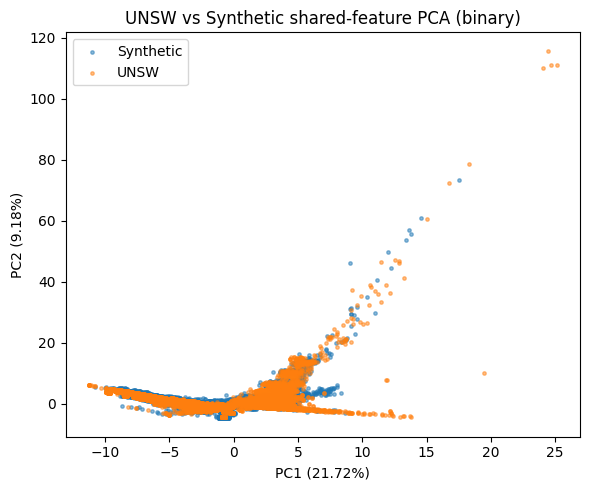

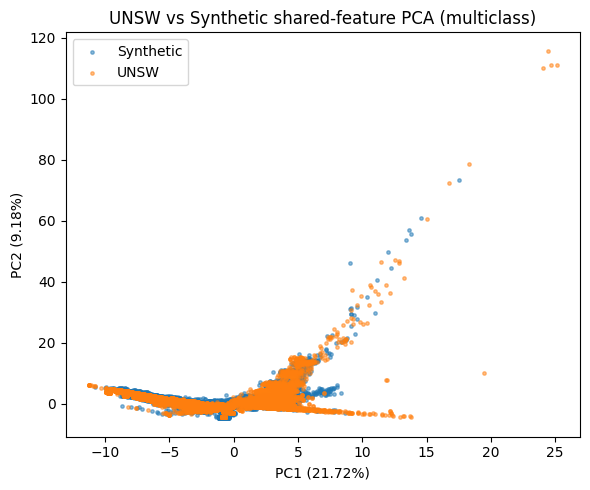

,task,n_unsw_cols,n_syn_cols,n_common_cols,jaccard,pc1_var,pc2_var
0,binary,42,53,42,0.792453,0.217216,0.091764
1,multiclass,42,53,42,0.792453,0.217216,0.091764


In [8]:
diag_rows = []

for task in ["binary", "multiclass"]:
    X_unsw, y_unsw, _, _, _ = prepare_unsw_task(task)
    _, _, X_syn, y_syn, _ = prepare_synthetic_task(task)

    overlap = feature_overlap(X_unsw.columns, X_syn.columns)
    (OUT / f"feature_overlap_{task}.json").write_text(json.dumps(overlap, indent=2))

    coords, domain, var_ratio, common = pca_projection(X_unsw, X_syn)
    df = pd.DataFrame({"pc1": coords[:, 0], "pc2": coords[:, 1], "domain": domain})
    df.to_csv(OUT / f"pca_projection_{task}.csv", index=False)

    plt.figure(figsize=(6, 5))
    for d in sorted(df["domain"].unique()):
        sub = df[df["domain"] == d]
        plt.scatter(sub["pc1"], sub["pc2"], s=6, alpha=0.5, label=d)
    plt.xlabel(f"PC1 ({var_ratio[0]:.2%})")
    plt.ylabel(f"PC2 ({var_ratio[1]:.2%})")
    plt.title(f"UNSW vs Synthetic shared-feature PCA ({task})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT / f"pca_projection_{task}.png", dpi=180, bbox_inches="tight")
    plt.show()

    diag_rows.append({
        "task": task,
        "n_unsw_cols": overlap["n_a"],
        "n_syn_cols": overlap["n_b"],
        "n_common_cols": overlap["n_common"],
        "jaccard": overlap["jaccard"],
        "pc1_var": float(var_ratio[0]),
        "pc2_var": float(var_ratio[1]),
    })

diag_df = pd.DataFrame(diag_rows)
diag_df.to_csv(OUT / "diagnostic_summary.csv", index=False)
display(diag_df)


## Optional UMAP Diagnostics

UMAP provides an additional nonlinear view of the same transfer problem when the package is available. It is optional because PCA already gives a reproducible baseline diagnostic.


2026-05-12 02:34:06.488654: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778553246.714975      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778553246.779475      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778553247.318445      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778553247.318500      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778553247.318504      57 computation_placer.cc:177] computation placer alr

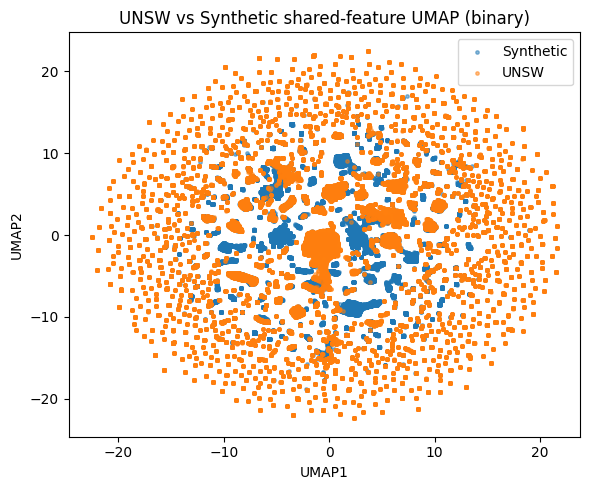

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisati

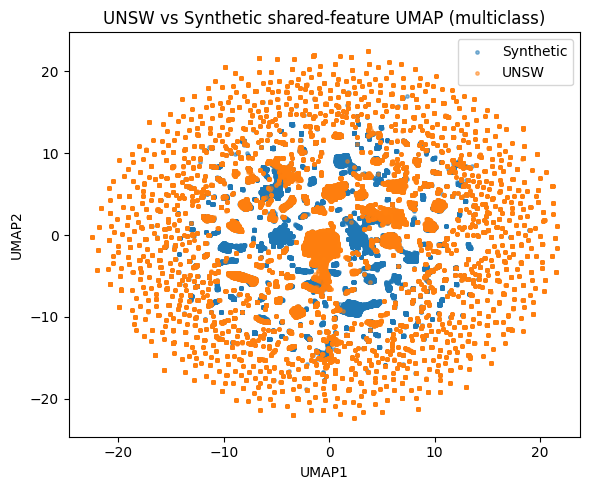

In [9]:
try:
    import umap

    for task in ["binary", "multiclass"]:
        X_unsw, _, _, _, _ = prepare_unsw_task(task)
        _, _, X_syn, _, _ = prepare_synthetic_task(task)
        Z_unsw, Z_syn, common = make_shared_design(X_unsw, X_syn)
        Z = np.vstack([Z_unsw, Z_syn])
        domain = np.array(["UNSW"] * len(Z_unsw) + ["Synthetic"] * len(Z_syn))

        reducer = umap.UMAP(n_components=2, random_state=42)
        coords = reducer.fit_transform(Z)

        dfu = pd.DataFrame({"umap1": coords[:, 0], "umap2": coords[:, 1], "domain": domain})
        dfu.to_csv(OUT / f"umap_projection_{task}.csv", index=False)

        plt.figure(figsize=(6, 5))
        for d in sorted(dfu["domain"].unique()):
            sub = dfu[dfu["domain"] == d]
            plt.scatter(sub["umap1"], sub["umap2"], s=6, alpha=0.5, label=d)
        plt.xlabel("UMAP1")
        plt.ylabel("UMAP2")
        plt.title(f"UNSW vs Synthetic shared-feature UMAP ({task})")
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUT / f"umap_projection_{task}.png", dpi=180, bbox_inches="tight")
        plt.show()
except Exception as e:
    print("UMAP skipped:", e)
